In [2]:
import pandas as pd

In [3]:


# Load all files
studentInfo = pd.read_csv("studentInfo.csv")
studentReg = pd.read_csv("studentRegistration.csv")
studentAssess = pd.read_csv("studentAssessment.csv")
courses = pd.read_csv("courses.csv")
assessments = pd.read_csv("assessments.csv")

# Quick summary of each
for name, df in [("studentInfo", studentInfo), 
                  ("studentRegistration", studentReg),
                  ("studentAssessment", studentAssess),
                  ("courses", courses),
                  ("assessments", assessments)]:
    print(f"{'='*40}")
    print(f"FILE: {name}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print()
# ```

# ---

# But also — let's move them to the right folder properly. In VS Code terminal run:
# ```
# move *.csv data\raw\

FILE: studentInfo
Shape: (32593, 12)
Columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']

FILE: studentRegistration
Shape: (32593, 5)
Columns: ['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration']

FILE: studentAssessment
Shape: (173912, 5)
Columns: ['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']

FILE: courses
Shape: (22, 3)
Columns: ['code_module', 'code_presentation', 'module_presentation_length']

FILE: assessments
Shape: (206, 6)
Columns: ['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']



In [4]:
# Most important column — your target variable
print("FINAL RESULT DISTRIBUTION:")
print(studentInfo['final_result'].value_counts())
print()
print(studentInfo['final_result'].value_counts(normalize=True).mul(100).round(1))

print("\nGENDER DISTRIBUTION:")
print(studentInfo['gender'].value_counts())

print("\nAGE DISTRIBUTION:")
print(studentInfo['age_band'].value_counts())

print("\nTOP MODULES:")
print(studentInfo['code_module'].value_counts())

print("\nNULL VALUES IN studentInfo:")
print(studentInfo.isnull().sum())

FINAL RESULT DISTRIBUTION:
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

final_result
Pass           37.9
Withdrawn      31.2
Fail           21.6
Distinction     9.3
Name: proportion, dtype: float64

GENDER DISTRIBUTION:
gender
M    17875
F    14718
Name: count, dtype: int64

AGE DISTRIBUTION:
age_band
0-35     22944
35-55     9433
55<=       216
Name: count, dtype: int64

TOP MODULES:
code_module
BBB    7909
FFF    7762
DDD    6272
CCC    4434
EEE    2934
GGG    2534
AAA     748
Name: count, dtype: int64

NULL VALUES IN studentInfo:
code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64


In [5]:
import numpy as np

In [6]:
# ── 1. Create Churn Label ────────────────────────────────────
# Withdrawn = churned, Pass/Distinction = successful
# We'll exclude Fail for now — they're a separate segment
studentInfo['churned'] = studentInfo['final_result'].map({
    'Withdrawn': 1,
    'Pass': 0,
    'Distinction': 0,
    'Fail': 0  # we treat fail as not churned for now
})

print("CHURN DISTRIBUTION:")
print(studentInfo['churned'].value_counts())
print()

# ── 2. Handle imd_band nulls ─────────────────────────────────
# Fill missing imd_band with 'Unknown'
studentInfo['imd_band'] = studentInfo['imd_band'].fillna('Unknown')
print("imd_band nulls after fix:", studentInfo['imd_band'].isnull().sum())

# ── 3. Encode categorical columns for ML later ───────────────
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cat_cols = ['gender', 'region', 'highest_education', 
            'imd_band', 'age_band', 'disability']

studentInfo_encoded = studentInfo.copy()
for col in cat_cols:
    studentInfo_encoded[col + '_encoded'] = le.fit_transform(studentInfo[col])

print("\nEncoded columns added successfully!")

# ── 4. Merge registration dates ──────────────────────────────
studentInfo_encoded = studentInfo_encoded.merge(
    studentReg[['id_student', 'code_module', 'code_presentation',
                'date_registration', 'date_unregistration']],
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

print("\nAfter merging registration data:")
print(studentInfo_encoded.shape)

# ── 5. Create early dropout flag ─────────────────────────────
# If unregistration date exists = dropped out
studentInfo_encoded['dropped_out'] = studentInfo_encoded['date_unregistration'].notnull().astype(int)
print("\nDropped out students:", studentInfo_encoded['dropped_out'].sum())

# ── 6. Merge assessment features ─────────────────────────────
# Get average score and number of assessments per student
assess_features = studentAssess.groupby('id_student').agg(
    avg_score=('score', 'mean'),
    num_assessments=('id_assessment', 'count'),
    avg_submission_day=('date_submitted', 'mean')
).reset_index()

studentInfo_encoded = studentInfo_encoded.merge(
    assess_features, on='id_student', how='left'
)

print("\nAfter merging assessment features:")
print(studentInfo_encoded.shape)
print("\nNull values in final dataset:")
print(studentInfo_encoded.isnull().sum())

# ── 7. Save cleaned data ─────────────────────────────────────
studentInfo_encoded.to_csv("cleaned.csv", index=False)
print("\n✅ Cleaned data saved!")


CHURN DISTRIBUTION:
churned
0    22437
1    10156
Name: count, dtype: int64

imd_band nulls after fix: 0

Encoded columns added successfully!

After merging registration data:
(32593, 21)

Dropped out students: 10072

After merging assessment features:
(32593, 25)

Null values in final dataset:
code_module                      0
code_presentation                0
id_student                       0
gender                           0
region                           0
highest_education                0
imd_band                         0
age_band                         0
num_of_prev_attempts             0
studied_credits                  0
disability                       0
final_result                     0
churned                          0
gender_encoded                   0
region_encoded                   0
highest_education_encoded        0
imd_band_encoded                 0
age_band_encoded                 0
disability_encoded               0
date_registration               45
date

In [7]:
# Fix remaining nulls

# 1. Registration date — fill with 0 (course start day)
studentInfo_encoded['date_registration'] = studentInfo_encoded['date_registration'].fillna(0)

# 2. Assessment nulls — students who never submitted anything
# Fill with -1 to flag them as "never engaged"
studentInfo_encoded['avg_score'] = studentInfo_encoded['avg_score'].fillna(-1)
studentInfo_encoded['num_assessments'] = studentInfo_encoded['num_assessments'].fillna(0)
studentInfo_encoded['avg_submission_day'] = studentInfo_encoded['avg_submission_day'].fillna(-1)

# 3. Create a powerful new feature — "never submitted" flag
studentInfo_encoded['never_submitted'] = (studentInfo_encoded['num_assessments'] == 0).astype(int)

print("Never submitted any assessment:", studentInfo_encoded['never_submitted'].sum())
print("Of those, how many churned?")
print(studentInfo_encoded[studentInfo_encoded['never_submitted']==1]['churned'].value_counts())

print("\nNull values remaining:")
print(studentInfo_encoded.isnull().sum().sum(), "total nulls")

# Save again
studentInfo_encoded.to_csv("cleaned.csv", index=False)
print("✅ Updated cleaned data saved!")

Never submitted any assessment: 5847
Of those, how many churned?
churned
1    4648
0    1199
Name: count, dtype: int64

Null values remaining:
22521 total nulls
✅ Updated cleaned data saved!


In [8]:
# Confirm remaining nulls are ONLY date_unregistration
print(studentInfo_encoded.isnull().sum()[studentInfo_encoded.isnull().sum() > 0])

date_unregistration    22521
dtype: int64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

df = studentInfo_encoded.copy()

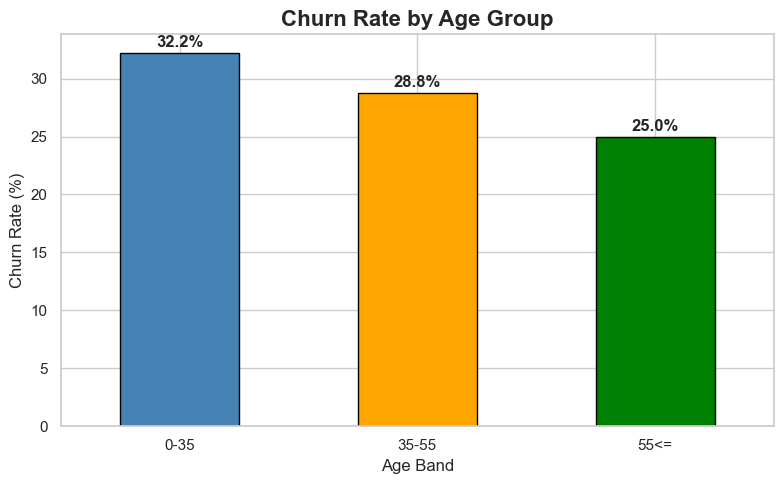

In [10]:
plt.figure(figsize=(8,5))
churn_age = df.groupby('age_band')['churned'].mean().mul(100).round(1)
churn_age.plot(kind='bar', color=['steelblue','orange','green'], edgecolor='black')
plt.title('Churn Rate by Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Age Band')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(churn_age):
    plt.text(i, v+0.5, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_churn_by_age.png', dpi=150)
plt.show()

In [11]:
print(df.groupby('age_band')['churned'].mean().mul(100).round(1))

age_band
0-35     32.2
35-55    28.8
55<=     25.0
Name: churned, dtype: float64


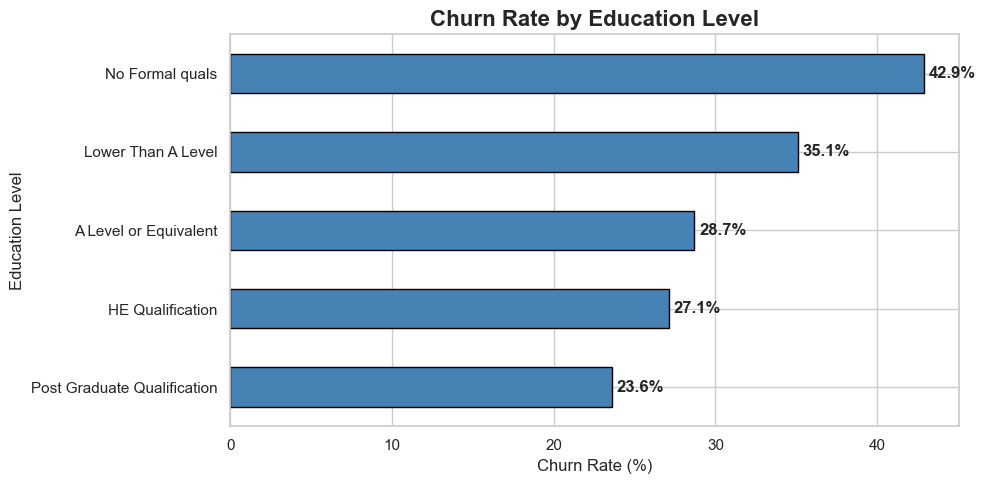

In [12]:
plt.figure(figsize=(10,5))
churn_edu = df.groupby('highest_education')['churned'].mean().mul(100).round(1).sort_values()
churn_edu.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Churn Rate by Education Level', fontsize=16, fontweight='bold')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Education Level')
for i, v in enumerate(churn_edu):
    plt.text(v+0.3, i, f'{v}%', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_churn_by_education.png', dpi=150)
plt.show()

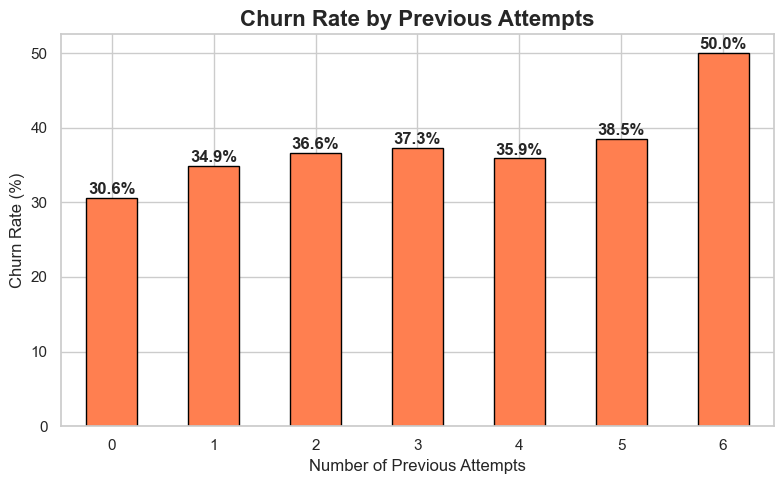

In [13]:
plt.figure(figsize=(8,5))
churn_attempts = df.groupby('num_of_prev_attempts')['churned'].mean().mul(100).round(1)
churn_attempts.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Churn Rate by Previous Attempts', fontsize=16, fontweight='bold')
plt.xlabel('Number of Previous Attempts')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(churn_attempts):
    plt.text(i, v+0.5, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_churn_by_attempts.png', dpi=150)
plt.show()

In [14]:
print(df.groupby('num_of_prev_attempts')['churned'].mean().mul(100).round(1))
print("\nNumber of students per attempt group:")
print(df['num_of_prev_attempts'].value_counts().sort_index())

num_of_prev_attempts
0    30.6
1    34.9
2    36.6
3    37.3
4    35.9
5    38.5
6    50.0
Name: churned, dtype: float64

Number of students per attempt group:
num_of_prev_attempts
0    28421
1     3299
2      675
3      142
4       39
5       13
6        4
Name: count, dtype: int64


### 🔍 Key Finding #4 — Each Retry Increases Churn Probability
- First time students: 30.6% churn
- Second attempt: 34.9% churn  
- Third attempt: 36.6% churn
- Each additional attempt adds ~2% more churn risk
- Note: 4+ attempt groups excluded due to small sample size (n<50)

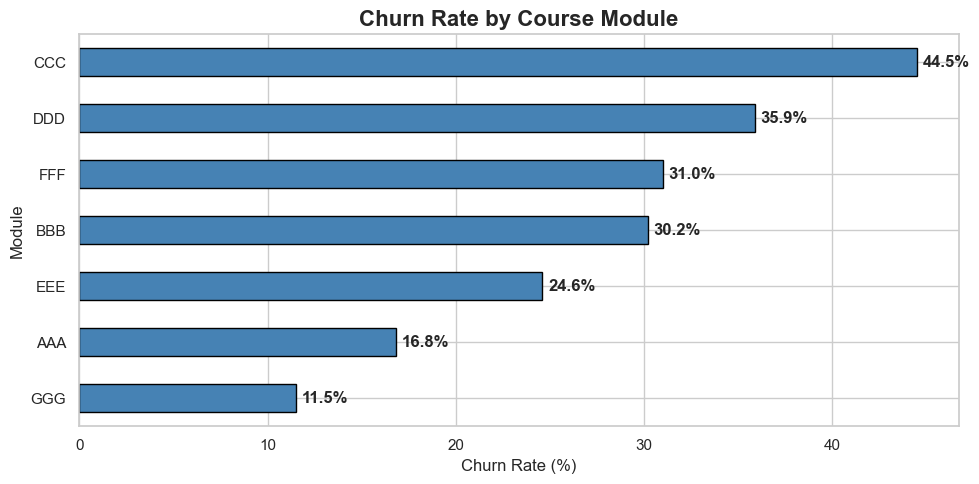

In [15]:
plt.figure(figsize=(10,5))
churn_module = df.groupby('code_module')['churned'].mean().mul(100).round(1).sort_values()
churn_module.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Churn Rate by Course Module', fontsize=16, fontweight='bold')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Module')
for i, v in enumerate(churn_module):
    plt.text(v+0.3, i, f'{v}%', va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_churn_by_module.png', dpi=150)
plt.show()

In [16]:
print(df.groupby('code_module')['churned'].mean().mul(100).round(1).sort_values())
print("\nStudents per module:")
print(df['code_module'].value_counts().sort_index())

code_module
GGG    11.5
AAA    16.8
EEE    24.6
BBB    30.2
FFF    31.0
DDD    35.9
CCC    44.5
Name: churned, dtype: float64

Students per module:
code_module
AAA     748
BBB    7909
CCC    4434
DDD    6272
EEE    2934
FFF    7762
GGG    2534
Name: count, dtype: int64


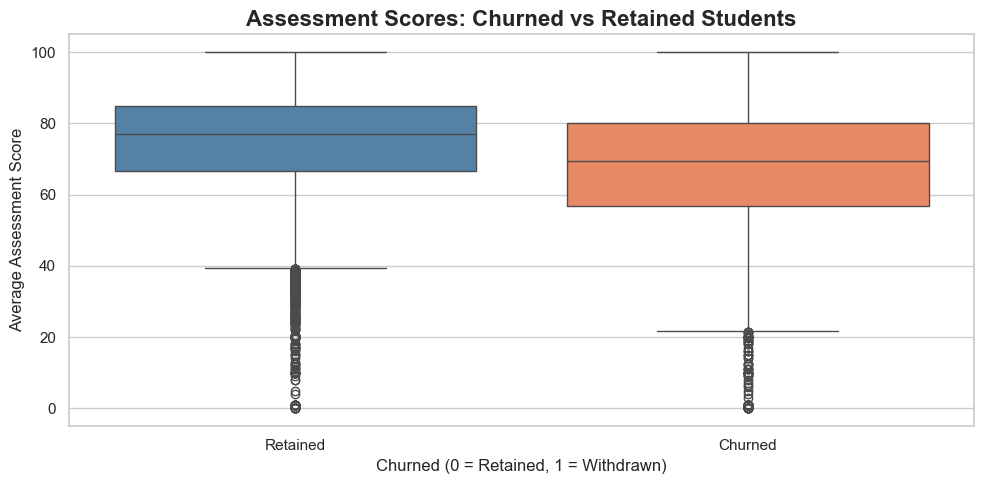

In [18]:
plt.figure(figsize=(10,5))

df_submitted = df[df['avg_score'] != -1]

sns.boxplot(data=df_submitted, x='churned', y='avg_score', 
            palette={'0':'steelblue', '1':'coral'})
plt.title('Assessment Scores: Churned vs Retained Students', 
          fontsize=16, fontweight='bold')
plt.xlabel('Churned (0 = Retained, 1 = Withdrawn)')
plt.ylabel('Average Assessment Score')
plt.xticks([0,1], ['Retained', 'Churned'])

for i, group in enumerate(['0','1']):
    mean_val = df_submitted[df_submitted['churned']==group]['avg_score'].mean()
    plt.text(i, mean_val+1, f'Mean: {mean_val:.1f}', 
             ha='center', fontweight='bold', color='black')

plt.tight_layout()
plt.savefig('chart5_score_vs_churn.png', dpi=150)
plt.show()

In [19]:
print("Mean scores:")
print(df_submitted.groupby('churned')['avg_score'].mean().round(1))



Mean scores:
churned
0    74.4
1    66.6
Name: avg_score, dtype: float64
